# Prototype clean gfw ais 

In [39]:
import pandas as pd
import os 

# Set

In [40]:
# To set
year = 2024

temporal_granularity = 'DAILY'
spatial_resolution= "HIGH" # LOW or MEDIUM or HIGH

#

inp_folder = '../data/raw'
inp_name = f'ais_{spatial_resolution.lower()}_{temporal_granularity.lower()}_ts_{str(year)}.parquet'

# Import 

In [41]:
input = os.path.join(inp_folder, inp_name)
df = pd.read_parquet(input)

# Clean

In [42]:
df.head(2)

,date,detections,flag,gear_type,hours,vessel_ids,vessel_id,vessel_type,entry_timestamp,exit_timestamp,first_transmission_date,last_transmission_date,imo,mmsi,call_sign,dataset,report_dataset,ship_name,lat,lon
0,2024-01-16,None,SVN,TRAWLERS,0.607778,None,16b116fd0-00c4-fd5a-b3fa-6fb643f7c576,FISHING,2024-01-03 12:00:00+00:00,2024-12-29 21:00:00+00:00,2014-04-25 07:48:52+00:00,2025-10-22 14:43:30+00:00,,278527000,S50Z8,public-global-vessel-identity:v3.0,public-global-fishing-effort:v3.0,JEZ,45.57,13.64
1,2024-06-17,None,SVN,TRAWLERS,0.977778,None,68a19f881-15e6-c87a-a0d4-3871277afd49,FISHING,2024-01-03 05:00:00+00:00,2024-12-29 17:00:00+00:00,2018-08-21 17:10:59+00:00,2025-10-13 07:25:27+00:00,,278956000,S5OK3,public-global-vessel-identity:v3.0,public-global-fishing-effort:v3.0,141-KP LUSTURA,45.61,13.58


In [43]:
cols_to_drop = [
    'detections',
    'vessel_ids',
    'entry_timestamp', 'exit_timestamp','last_transmission_date', 'first_transmission_date',
    'imo', 'call_sign',
    'dataset', 'report_dataset',
    'vessel_type',
    'vessel_id'
]

df = df.drop(columns=cols_to_drop)

In [44]:
df.head()

,date,flag,gear_type,hours,mmsi,ship_name,lat,lon
0,2024-01-16,SVN,TRAWLERS,0.607778,278527000,JEZ,45.57,13.64
1,2024-06-17,SVN,TRAWLERS,0.977778,278956000,141-KP LUSTURA,45.61,13.58
2,2024-07-24,ITA,TRAWLERS,1.014167,247050940,RINA S.,45.64,13.33
3,2024-12-11,ITA,TRAWLERS,0.325556,247030160,USODIMARE,45.60,13.40
4,2024-07-07,ITA,TRAWLERS,0.961667,247050940,RINA S.,45.67,13.24


In [45]:
rename_dict = {
    'lat': 'latitude',
    'lon': 'longitude'
    }

df = df.rename(columns=rename_dict)

In [46]:
df.head()

,date,flag,gear_type,hours,mmsi,ship_name,latitude,longitude
0,2024-01-16,SVN,TRAWLERS,0.607778,278527000,JEZ,45.57,13.64
1,2024-06-17,SVN,TRAWLERS,0.977778,278956000,141-KP LUSTURA,45.61,13.58
2,2024-07-24,ITA,TRAWLERS,1.014167,247050940,RINA S.,45.64,13.33
3,2024-12-11,ITA,TRAWLERS,0.325556,247030160,USODIMARE,45.60,13.40
4,2024-07-07,ITA,TRAWLERS,0.961667,247050940,RINA S.,45.67,13.24


In [47]:
# re order columns 
cols = [
    'date', 'latitude', 'longitude', 'gear_type', 'mmsi', 'ship_name',  'hours', 'flag'
]

df = df[cols]

In [48]:
df.head()

,date,latitude,longitude,gear_type,mmsi,ship_name,hours,flag
0,2024-01-16,45.57,13.64,TRAWLERS,278527000,JEZ,0.607778,SVN
1,2024-06-17,45.61,13.58,TRAWLERS,278956000,141-KP LUSTURA,0.977778,SVN
2,2024-07-24,45.64,13.33,TRAWLERS,247050940,RINA S.,1.014167,ITA
3,2024-12-11,45.60,13.40,TRAWLERS,247030160,USODIMARE,0.325556,ITA
4,2024-07-07,45.67,13.24,TRAWLERS,247050940,RINA S.,0.961667,ITA


# Clean nation

In [49]:
import matplotlib.pyplot as plt
gulf_df = pd.read_csv('../data/raw/ts_gulf_coords.csv')
unq_coords = df.drop_duplicates(subset=['latitude', 'longitude']).copy()

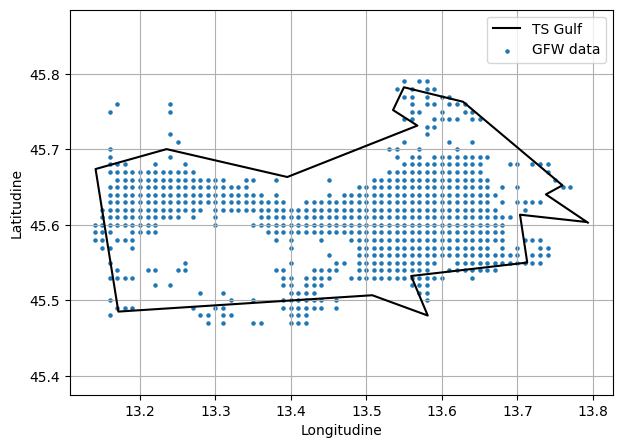

In [50]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.scatter(unq_coords['longitude'], unq_coords['latitude'], label = 'GFW data', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [51]:
df = df [
    df['flag'] == 'ITA'
].copy()

In [52]:
ita_unq_coords = df.drop_duplicates(subset=['latitude', 'longitude']).copy()

In [53]:
#bound_lats = [45.60, 45.63, 45.57, 45.55, 45.45]
#bound_lons = [13.72,13.63,13.39, 13.31, 13.21]
#
#bounds_df = pd.DataFrame(
#    {
#        'latitude': bound_lats,
#        'longitude': bound_lons
#    }
#)
#
#bounds_df.to_csv('../data/raw/italy_marine_bounds.csv', index=False)

In [54]:
bounds_df = pd.read_csv('../data/raw/italy_marine_bounds.csv')

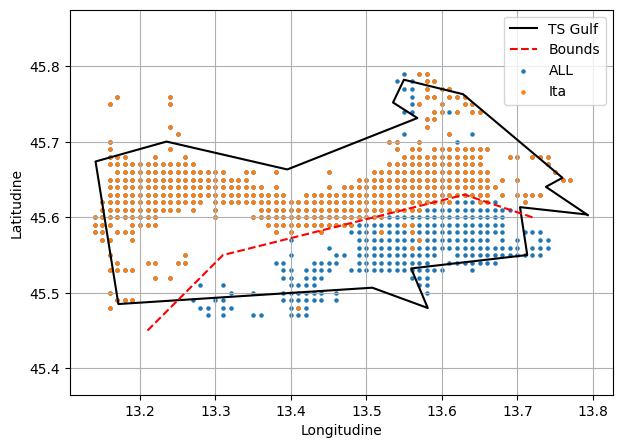

In [55]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(unq_coords['longitude'], unq_coords['latitude'], label = 'ALL', s = 5)
plt.scatter(ita_unq_coords['longitude'], ita_unq_coords['latitude'], label = 'Ita', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

In [56]:
import geopandas as gpd
from shapely.geometry import LineString, Point

def filter_above_boundary(df, bounds_df):
    # --- Boundary ---
    boundary_line = LineString(zip(bounds_df.longitude, bounds_df.latitude))

    # --- Ship points ---
    gdf = gpd.GeoDataFrame(
        df,
        geometry=[Point(xy) for xy in zip(df.longitude, df.latitude)]
    )

    def is_above_line(point, line):
        projection = line.interpolate(line.project(point))
        return point.y > projection.y

    gdf["above"] = gdf.geometry.apply(lambda p: is_above_line(p, boundary_line))

    filtered = gdf[gdf["above"]]
    
    return filtered.drop(columns=['geometry', 'above'])


In [57]:
filtered = filter_above_boundary(df, bounds_df)

In [58]:
fil_unq_coords = filtered.drop_duplicates(subset=['latitude', 'longitude']).copy()

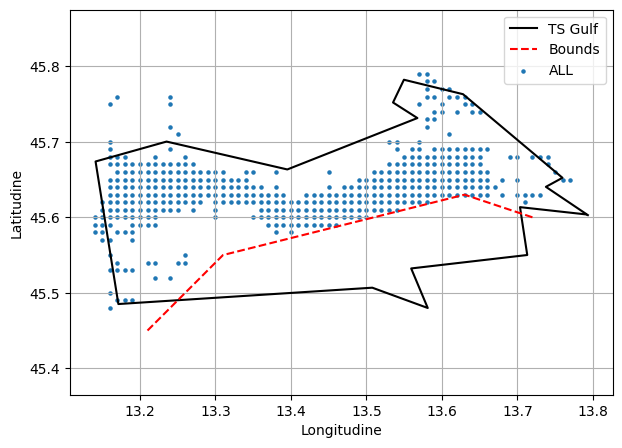

In [59]:
plt.figure(figsize=(7,5))

plt.plot(gulf_df['longitude'], gulf_df['latitude'], label = 'TS Gulf', color = 'black')
plt.plot(bounds_df['longitude'], bounds_df['latitude'], label = 'Bounds', color = 'red', linestyle='--')
plt.scatter(fil_unq_coords['longitude'], fil_unq_coords['latitude'], label = 'ALL', s = 5)
plt.xlim(13,14)
plt.ylim(45.3,45.9)
plt.xlabel("Longitudine")
plt.ylabel("Latitudine")
plt.grid(True)
plt.axis("equal")
plt.legend()

plt.show()

# Export

In [61]:
out_dir = '../data/interim'
out_name = f'cleaned_{inp_name}'
out = os.path.join(out_dir, out_name)

filtered.to_parquet(out, index=False)